In [23]:
import os
import faiss
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from tensorflow.keras.applications import ResNet50

from tensorflow.keras.applications.resnet50 import(
    preprocess_input
)

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

In [12]:
image_embeddings=np.load(
    "shoe_image_embeddings.npy"
)

image_filenames=np.load(
    "shoe_image_filenames.npy",
    allow_pickle=True
)

print(image_embeddings.shape)
print(len(image_filenames))

(2000, 2048)
2000


In [13]:
image_embeddings=image_embeddings.astype("float32")

faiss.normalize_L2(image_embeddings)

In [14]:
dimension=image_embeddings.shape[1]

image_index=faiss.IndexFlatIP(
    dimension
)

In [15]:
image_index.add(
    image_embeddings
)

In [5]:
dataset_path = r"sampled_sneakers_1024x1024"

In [6]:
base_model=ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [7]:
x=GlobalAveragePooling2D()(
    base_model.output
)

feature_extractor=Model(
    inputs=base_model.input,
    outputs=x
)

In [8]:
def preprocess_image(img_path):

    img=image.load_img(
        img_path,
        target_size=(224, 224)                #ResNet expects 224x224 image.
    )

    img_array=image.img_to_array(img)

    img_array=np.expand_dims(               #converts (a, b, c) shape -> (1, a, b, c), batches are expected in tensorflow even if size of 1.
        img_array,
        axis=0
    )

    img_array=preprocess_input(
        img_array
    )

    return img_array

In [9]:
def get_embedding(img_path):

    processed_img=preprocess_image(
        img_path
    )

    embedding=feature_extractor.predict(
        processed_img,
        verbose=0
    )

    return embedding.flatten()

In [25]:
def show_results(query_image_path, results):
    plt.figure(figsize=(15, 5))                           #figure->page, subplot->divides page into sections, imshow->puts image in one section.

    #query image
    plt.subplot(1, len(results)+1, 1)

    query_img=image.load_img(
        query_image_path,
        target_size=(224, 224)
    )

    plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    #retrieved image
    for i, result in enumerate(results):
        filename = result["filename"]
        score = result["similarity"]
        
        img_path=os.path.join(
            dataset_path,
            filename
        )

        img=image.load_img(
            img_path,
            target_size=(224, 224)
        )

        plt.subplot(1, len(results)+1, i+2)

        plt.imshow(img)

        plt.title(f"{score:.2f}")

        plt.axis("off")

    plt.show()

In [26]:
def retrieve_similar_images_faiss(query_image_path, top_k=5):
    query_embedding=get_embedding(
        query_image_path
    )

    query_embedding = np.expand_dims(
        query_embedding,
        axis=0
    ).astype("float32")

    faiss.normalize_L2(query_embedding)

    similarities, indices = image_index.search(
        query_embedding,
        top_k
    )

    results = []

    for sim, idx in zip(similarities[0], indices[0]):
        results.append({
            "filename":
            str(image_filenames[idx]),

            "similarity":
            float(sim)
        })

    return results

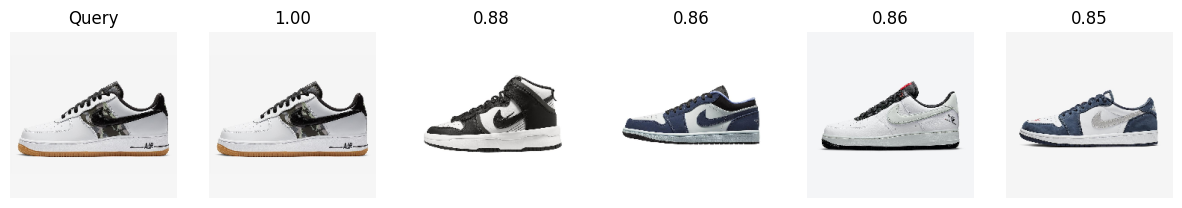

In [27]:
#test
query_image = os.path.join(
    dataset_path,
    image_filenames[100]
)

results = retrieve_similar_images_faiss(
    query_image,
    top_k=5
)

show_results(query_image, results)